### Partitioning Homework

The purpose of this homework is to build intuition about the different partitioning algorithms by applying them to a couple of informative graphs. The homework doesn't include the Girvan-Newman edge betweenness partitioning method since you've already done a homework problem for this algorithm.

The homework has you explore the folllowing partitioning algorithms
- Modularity-based methods
  - Spectral modularity partition
  - Louvain algorithm modularity partition
- Graph cut methods
  - Kernighan-Lin hill-climbing partition
  - Spectral modularity partition using
    - Graph Laplacian $L=D-V$
    - Random walk Laplacian $LD^{-1}$
    - Normalized Laplacian $D^{-1/2}LD^{-1/2}$

---


### Visualization Routines

I've collected the visualization routines into a python file called _partitioning\_utilities_. That file also contains each of the modularity cut and graph cut algorithms that we've discussed (plus their helper functions). Import the visualization routines.

In [35]:
from drawing_utilities import show_partitions, show_dendrogram, show_graph
import networkx as nx
from typing import Hashable

---

### Three Networks

You'll apply the algorithms to three networks
  - The Les Miserables network
  - A network with three "natural" communities
  - A small world network

Let's visualize each, along with the dendrogram.

**Les Miserables network**

Vertices represent characters in the book _Les Miserables_. Edges between vertices occur if two characters appear in the same scene.

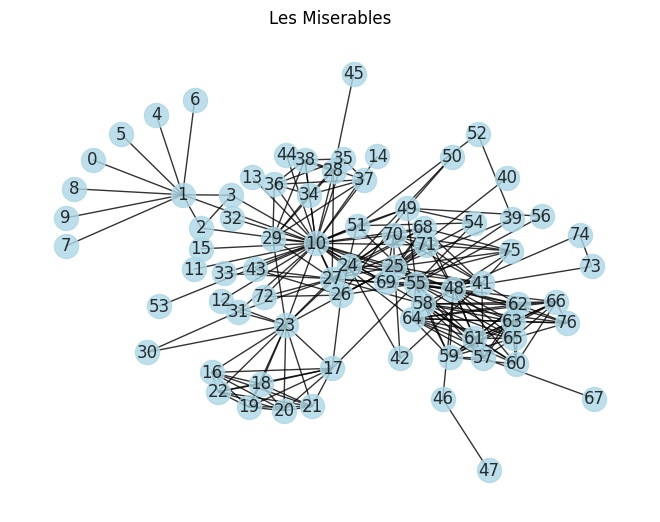

In [36]:
les_mis_graph = nx.les_miserables_graph()
# The labels of the nodes are character names. 
# Change these to ints so things display better
mapping = {name: i for i, name in enumerate(les_mis_graph.nodes())}
les_mis_graph = nx.relabel_nodes(les_mis_graph, mapping)
show_graph(les_mis_graph,title = "Les Miserables")


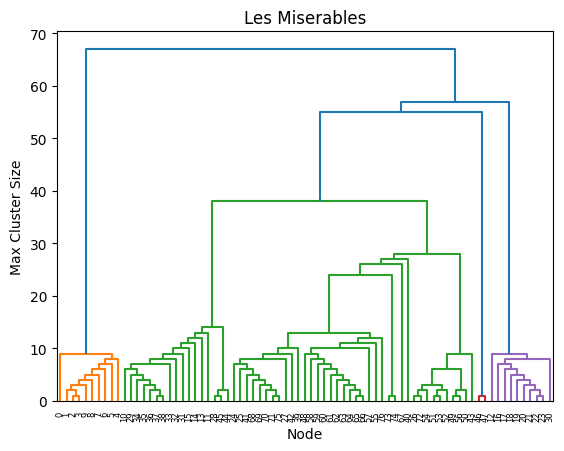

In [6]:
show_dendrogram(les_mis_graph, title="Les Miserables", height_metric="max_cluster")

**Network with Natural Communities**

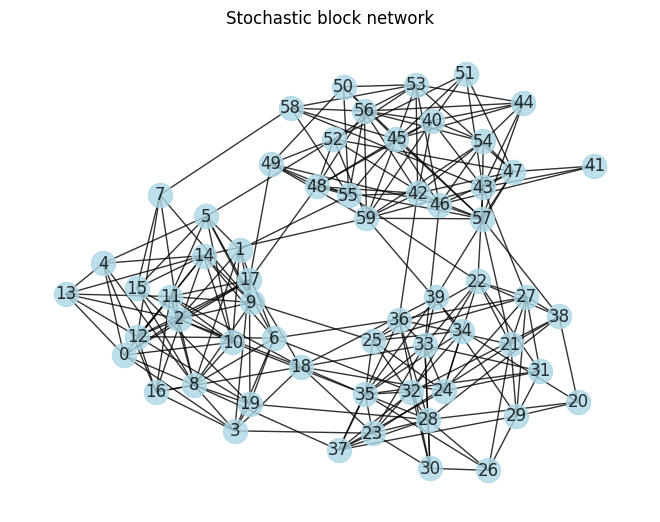

In [37]:
sizes = [20, 20, 20]
probs = [[0.35, 0.02, 0.02], [0.02, 0.35, 0.02], [0.02, 0.02, 0.40]]
affinity_graph = nx.stochastic_block_model(sizes, probs, seed=42)
show_graph(affinity_graph, title = "Stochastic block network")

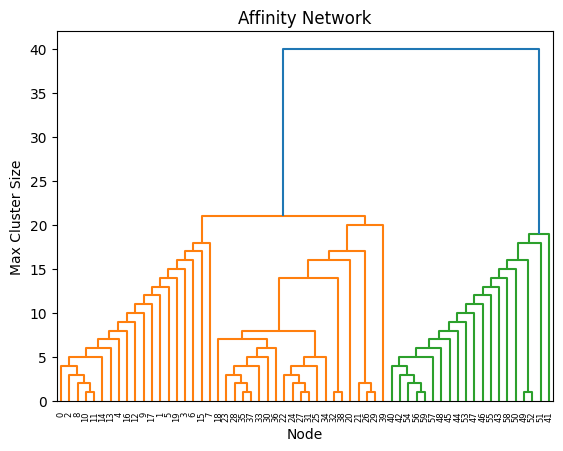

In [26]:
show_dendrogram(affinity_graph, title="Affinity Network", height_metric="max_cluster")

**Small World Network**

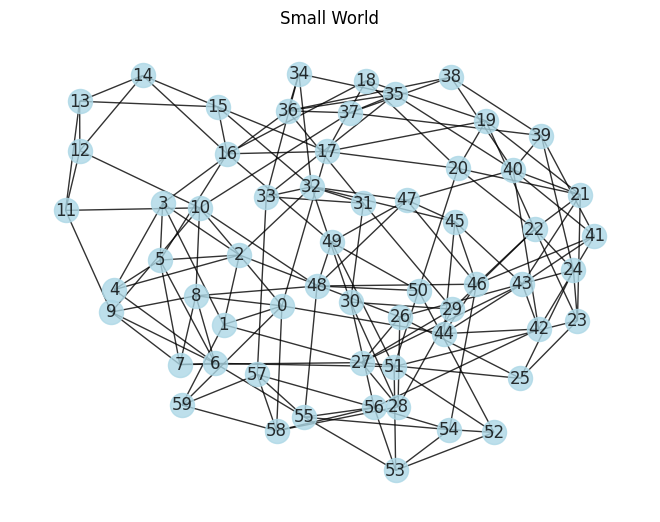

In [38]:
small_world = nx.newman_watts_strogatz_graph(60, 4, 0.3, seed = 42)
show_graph(small_world, title = "Small World")

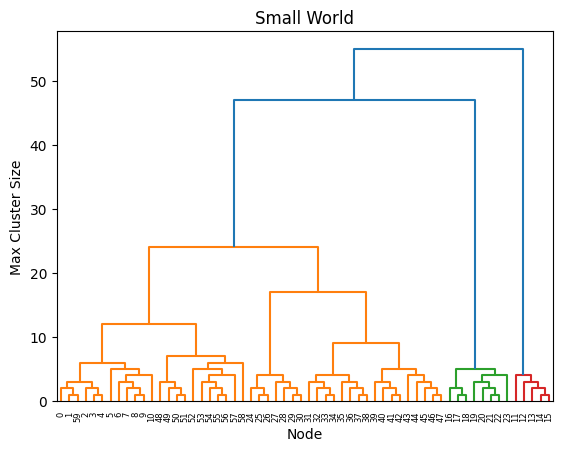

In [28]:
show_dendrogram(small_world, title = "Small World", height_metric="max_cluster")

---

### Question Block A: Communities Found by the Louvain Algorithm

The following three questions are intended to build understanding of how well the Louvain algorithm works with the default parameters and what happens when we change the resolution parameter. 

The _resolution_ parameter influences whether the Louvain community detection algorithm favors a partition with many groups or few groups. The higher the parameter, the more the algorithm favors many groups in the partition, with each group having few members. The lower the parameter, the more the algorithm favors few groups in the partition, with each group having many members. 

### Problem 1: Louvain algorithm for the Affinity Graph

    Answer the questions in Problems a, b, and c before you run the code in the next three cells. Answer question d after you run the code in the next three cells.

**Problem 1a:**
How many communities do you predict will be found for the default parameters of the Louvain algorithm? Justify your prediction using observations from the dendrogram.

I believe that there will be 3 communities found from the Louvain algorithm. In the dendrogram it has two obvious groups, the orange and green, but the green one seems to be two groups that joined together at the very last minute with a bridge between them. Based on this and just looking at the graph and seeing what looks like 3 obvious groups, there will most likely be 3.

**Problem 1b:**
What do you predict will happen if you raise the resolution parameter from the default value of 1.0 to 1.5? Why?

I think the communities will stay roughly the same, there will still be 3 of them. The communities in the original network seem strong, without many nodes that could be in a different group as there isn't many connections between the groups. The only thing that could change is maybe node 18 or 57, as those are the only nodes with multiple edges linking them to a different group.

**Problem 1c:**
What do you predict will happen if you lower the resolution parameter from the default value of 1.0 to 0.5? Why?

The communities seem strongly connected, with all the nodes in the communities stringly connected with each other and weakly connected to other communities, so while maybe it could go into two groups I think it'll stay consistent as the same 3 groups that were in the original run.

**Problem 1d:**
Run the code below. Were your predictions correct? What can you conclude from the experiment about the modular structure of the affinity graph?

My predictions were right, since each run of the algorithm consistently has three communities with little to no changes in them the modular structure is pretty strong.

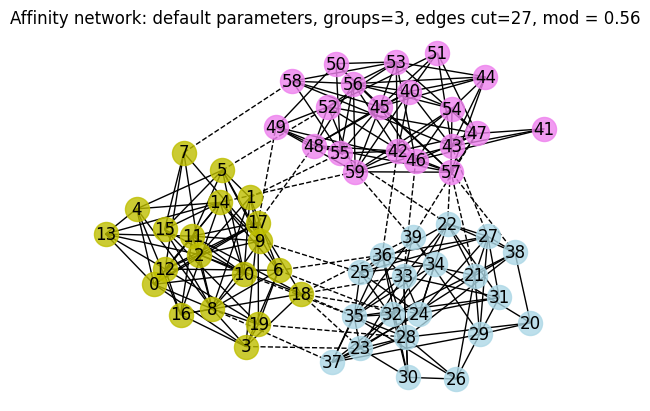

In [11]:
seed = 42
partition: list[set[Hashable]] = nx.community.louvain_communities(affinity_graph,
                                                                  seed=seed)
show_partitions(affinity_graph, 
                partition=partition,
                title="Affinity network: default parameters")

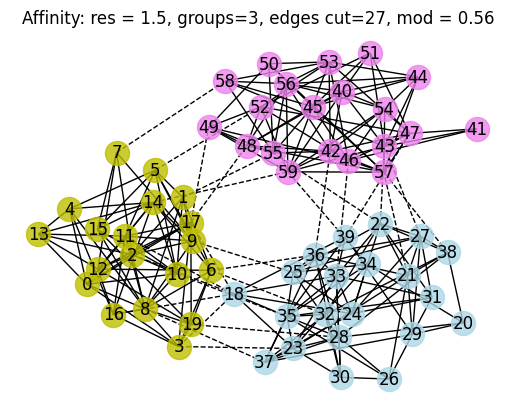

In [12]:
seed = 42
resolution: float = 1.5
partition: list[set[Hashable]] = nx.community.louvain_communities(affinity_graph,
                                                                  seed=seed,
                                                                  resolution = resolution)
show_partitions(affinity_graph, 
                partition=partition,
                title=f"Affinity: res = {resolution}")

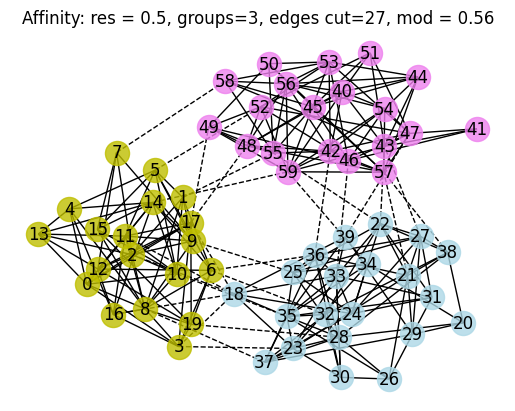

In [13]:
seed = 42
resolution: float = 0.5
partition: list[set[Hashable]] = nx.community.louvain_communities(affinity_graph,
                                                                  seed=seed,
                                                                  resolution = resolution)
show_partitions(affinity_graph, 
                partition=partition,
                title=f"Affinity: res = {resolution}")

---

### Problem 2: Louvain algorithm for the Les Miserables Network

    Answer the questions in Problems a, b, and c before you run the code in the next three cells. Answer question d after you run the code in the next three cells.

**Problem 2a:**
How many communities do you predict will be found for the default parameters of the Louvain algorithm? Justify your prediction using observations from the dendrogram.

Based on the dendrogram, there is most likely a lot more less defined communities, probably around six. The dendrogram shows three sections where nodes merge relatively early, showing there are strong relationships between those communities. One of those groups has more merges that occur higher up, implying that they aren't as highly connected and will be split into seperate communities. Most likely they will split into four communities with the two more connected ones, resulting in six communities

**Problem 2b:**
What do you predict will happen if you raise the resolution parameter from the default value of 1.0 to 1.5? Why?

If they raise the resolution, because of how weak the connections are, I can see some of them splitting into smaller communities, maybe adding one or two more to make eight communities. Most likely the nodes will also be moved around, as in the last graph some of the weaker connected nodes moved communities.

**Problem 2c:**
What do you predict will happen if you lower the resolution parameter from the default value of 1.0 to 0.5? Why?

Because of some of the groups are only weakly separated, lowering the resolution would likely cause these weakly separated communities to merge into one community, leaving around four communities left.

**Problem 2d:**
Run the code below. Were your predictions correct? What can you conclude from the experiment about the modular structure of the affinity graph?

I was mostly right, I overestimated how many groups would be merged for the lower resoltion but the rest of my predictions were right. This network has a slightly weak modular structure, with some of the communities sticking around after the resolution was changed with others split or merge as soon as it does.

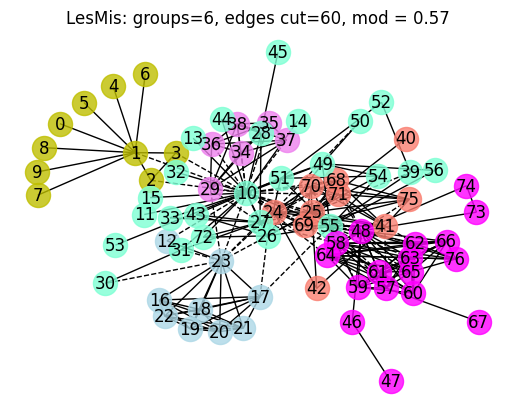

In [19]:
seed = 42
partition: list[set[Hashable]] = nx.community.louvain_communities(les_mis_graph,
                                                                  seed=seed)
show_partitions(les_mis_graph, 
                partition=partition,
                title="LesMis:")

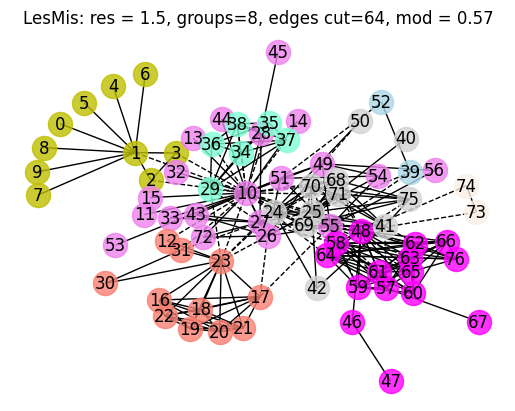

In [20]:
seed = 42
resolution: float = 1.5
partition: list[set[Hashable]] = nx.community.louvain_communities(les_mis_graph,
                                                                  seed=seed,
                                                                  resolution = resolution)
show_partitions(les_mis_graph, 
                partition=partition,
                title=f"LesMis: res = {resolution}")

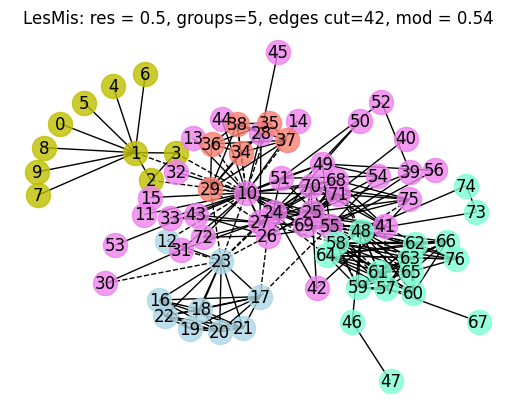

In [21]:
seed = 42
resolution: float = 0.5
partition: list[set[Hashable]] = nx.community.louvain_communities(les_mis_graph,
                                                                  seed=seed,
                                                                  resolution = resolution)
show_partitions(les_mis_graph, 
                partition=partition,
                title=f"LesMis: res = {resolution}")

---

### Problem 3: Louvain algorithm for the Small World Graph

    Answer the questions in Problems a, b, and c before you run the code in the next three cells. Answer question d after you run the code in the next three cells.

**Problem 3a:**
How many communities do you predict will be found for the default parameters of the Louvain algorithm? Justify your prediction using observations from the dendrogram.

There are two groups that are obvious in the dendrogram, which aren't connected to the other communities. Then there are also seven other small groups that start to merge early on, then these merged groups merge much later. Leaving about four other, weakly connected communities for a total of six communities.

**Problem 3b:**
What do you predict will happen if you raise the resolution parameter from the default value of 1.0 to 1.5? Why?

If the resolution increases, one of the communities is only loosely connected, and has a higher merge point than the other communities, so most likely that one will split into two, meaning there'd be seven communities total.

**Problem 3c:**
What do you predict will happen if you lower the resolution parameter from the default value of 1.0 to 0.5? Why?

The two communities in the far left of the dendrogram merge a bit later than the other communities, enough to be separate but still close. If the resolution goes down my guess is those will merge into one, leaving five communities.

**Problem 3d:**
Run the code below. Were your predictions correct? What can you conclude from the experiment about the modular structure of the affinity graph?

I was correct with the first prediction, but not with the other two, with both of them cutting or adding more communities than I expected. Since the communities changed a lot as the resolution changed, this means the graph is very weakly connected, as the nodes can merge or break off from communities very easily. 

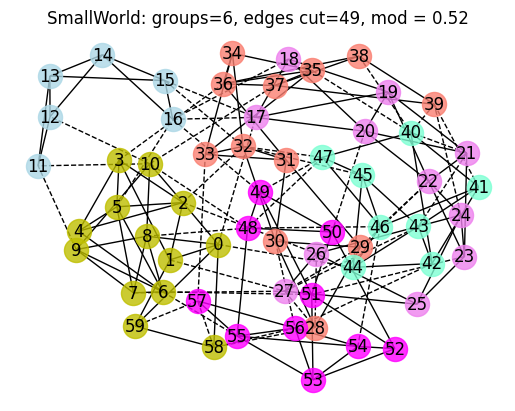

In [30]:
seed = 42
partition: list[set[Hashable]] = nx.community.louvain_communities(small_world,
                                                                  seed=seed)
show_partitions(small_world, 
                partition=partition,
                title="SmallWorld:")

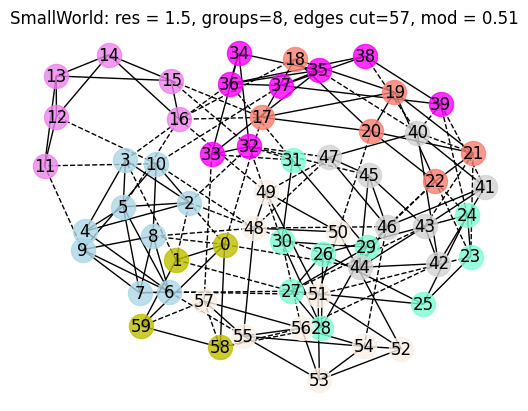

In [31]:
seed = 42
resolution: float = 1.5
partition: list[set[Hashable]] = nx.community.louvain_communities(small_world,
                                                                  seed=seed,
                                                                  resolution = resolution)
show_partitions(small_world, 
                partition=partition,
                title=f"SmallWorld: res = {resolution}")


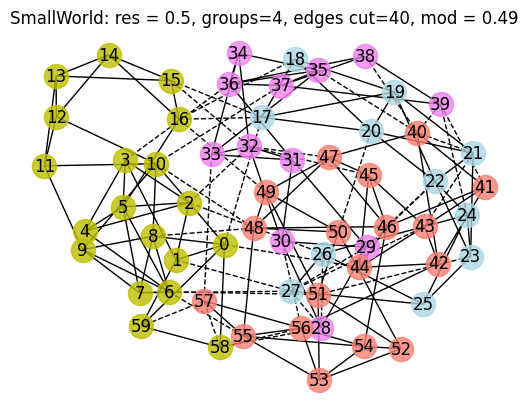

In [32]:

seed = 42
resolution: float = 0.5
partition: list[set[Hashable]] = nx.community.louvain_communities(small_world,
                                                                  seed=seed,
                                                                  resolution = resolution)
show_partitions(small_world, 
                partition=partition,
                title=f"SmallWorld: res = {resolution}")

---
---

### Homework Questions about Decomposition Algorithms

The next questions are about the decomposition algorithms:
  - Modularity-based partitioning
    - Newman's hill-climbing algorithm
    - The spectral partitioning algorithm using the leading eigenvector from the modularity matrix $B$
  - Graph cut-based partitioning
    - The Kernighan-Lin hill-climbing algorithm
    - The spectral partitioning algorithm using the fiedler eigenvector from for two of the three types of Laplacians
      - $L$: the standard Laplacian
      - $D^{-1/2}LD^{-1/2}$: the normalized Laplacian

Each of these decomposition algorithms partitions a set of nodes into two subsets. I think it is helpful to split the graph into more than two groups so that the outcomes of the algorithms can be compared to the partition generated by the Louvain algorithm. 

The code in the following cell takes a partition, finds the largest group within that partition, and splits that group. The key argument is the partitioning method to be used. This argument is a function that implements one of the algorithms above. That makes it possible to iteratively _sub-partition_ the groups until you have the same number of groups as were found by the Louvain algorithm.

In [40]:
from typing import Hashable, List, Set
from typing import Callable as function

def sub_partition(G: nx.Graph,
                  partition: List[Set[Hashable]],
                  partition_method: function
                  ) -> List[Set[Hashable]]:
    """ 
        Input: 
            • a networkx Graph
            • a list of subsets of the nodes in the graph that partition the nodes
            • a function that can be used to partition the nodes
        Algorithm:
            • find the group in the partition that has the most nodes
            • copy the remaining groups from that partition into a new partition
            • split the largest group by creating the subgraph and calling the partition function
            • add the newly formed subsets of the split group to the new partition

    """
    # make sure groups actually form a partition of G.nodes
    if set(G.nodes()) != set().union(*partition):  # The * unpacks the list
        raise ValueError("partition doesn't include all nodes in the graph")
    # find largest group
    largest_group: Set[Hashable] = max(partition, key=len)
    # new partition = the old minus the largest group
    new_partition: List[Set[Hashable]] = list(s for s in partition if s != largest_group)
    # form subgraph made up of largest group
    graph_of_partition: nx.Graph = nx.Graph(G.subgraph(largest_group))
    # partition the subgraph
    sub_partition = partition_method(graph_of_partition)
    # add the new grups from the subgraph into the new partition
    new_partition.extend(sub_partition)
    return new_partition

### Question Block B: Modularity-Based Partitions

Both Newman hill climbing and the leading eigenvalue of the modularity matrix split the nodes into two sets. To find more than two groups in the partition you have to apply the algorithm again on one of the groups in the partition.
 
 Import the code from _partitioning\_utilities_. The code is a slightly modified version of the code you played with in class.


In [42]:
from partitioning_utilities import Newman_hill_climbing
from partitioning_utilities import modularity_spectral_split


### Problem 4: Newman Hill-Climbing

    Answer problems 4a and 4b before you run any code. Answer problems 4c and 4d after you've run code.

**Problem 4a:**
On which of the networks (affinity graph, Les Miserables graph, small world network) do you predict that Newman Hill-Climbing will work well? Justify your answer using your understanding for how hill-climbing works compared to how the Louvain algorithm works.

Since the Newman Hill-Climbing algorithm looks for better solutions among neighbors, my guess is the affinity graph will work the best with the algorithm, as it has obvious communities and doesn't have many connections between communities. That gives it the best chance to create the best communities without making a mistake, as the communities are obviously separated and it is less likely to pick a connecting edge when it shouldn't.

**Problem 4b:**
How much will your answer to problem 4a be affected by the randomness used in the hill-climbing algorithm? In other words, how sensitive is the partition found by the algorithm to randomness for the various networks?

I can see the randomness maybe having a negative affect, if the algorithm makes a bad merge early in the process it can't fix that and the communities made may be wrong, which would most likely be the case for the les mis and small world graphs that have weak connections between communities. However, since the connections are strong within communities and have few connections linking communities in the affinity graph I can see it having minimal affect.

**Problem 4c:**
Run the code in the cells below. Was your answer to question 4a correct? Why or why not?

Yes, the affinity graph was obviously the best one as it was the only one which had obvious, mostly unchanging communities. The other two had communities that seemed unstable and not as obviously grouped, and didn't do as well because of the communities weak connections and more edges between groups, which made this algorithm worse. 

**Problem 4d:**
Run in the code in the cells below a few times. Was your answer to question 4b correct? Why or why not?

It was mostly right, although the randomness did affect the affinity graph more than I expected. There was almost always at least one node in a different group when rerunning, and there was one odd time that one of the communities took a lot of the nodes from what should have been a separate community. This is because the algorithm cannot take back its decisions, so one bad merge can result in a different path being taken and the communities differing.

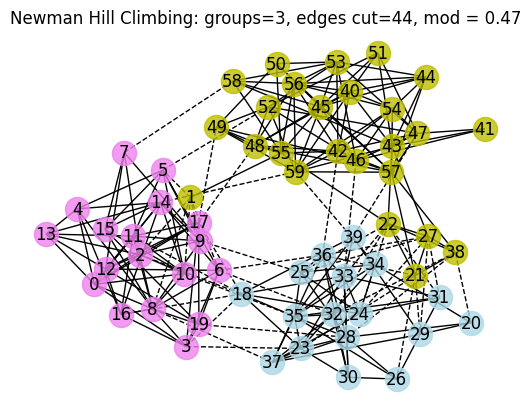

In [49]:
G = affinity_graph
Louvain_partition: list[set[Hashable]] = nx.community.louvain_communities(G,seed = seed)
partition = Newman_hill_climbing(G)
while len(partition) < len(Louvain_partition):
    partition = sub_partition(G, partition, partition_method=Newman_hill_climbing) 

show_partitions(G, 
                partition=partition,
                title="Newman Hill Climbing:")

Les Miserables graph

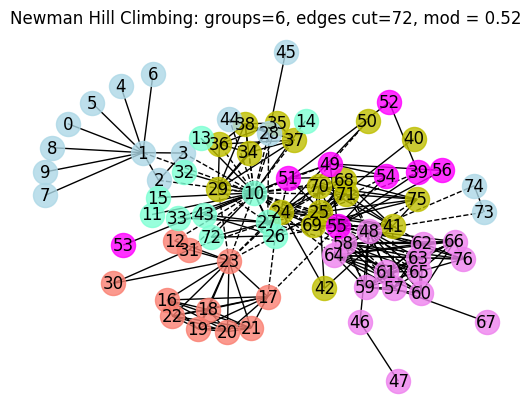

In [51]:
G = les_mis_graph
Louvain_partition: list[set[Hashable]] = nx.community.louvain_communities(G,seed = seed)
partition = Newman_hill_climbing(G)
while len(partition) < len(Louvain_partition):
    partition = sub_partition(G, partition,partition_method=Newman_hill_climbing) 

show_partitions(G, 
                partition=partition,
                title="Newman Hill Climbing:")

Small world graph

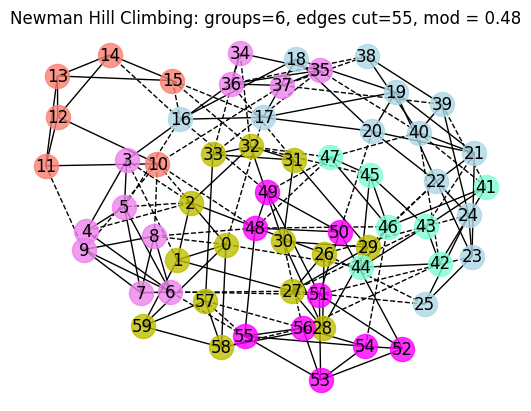

In [52]:
G = small_world
Louvain_partition: list[set[Hashable]] = nx.community.louvain_communities(G,seed = seed)
partition = Newman_hill_climbing(G)
while len(partition) < len(Louvain_partition):
    partition = sub_partition(G, partition,partition_method=Newman_hill_climbing) 

show_partitions(G, 
                partition=partition,
                title="Newman Hill Climbing:")

---

### Problem 5: Spectral Split using the Modularity Matrix

    Answer problems 5a and 5b before you run any code. Answer problems 5c and 5d after you've run code.

**Problem 5a:**
On which of the networks (affinity graph, Les Miserables graph, small world network) do you predict that modularity spectral split will work best? Justify your answer using your understanding of the leading eigenvector of the modularity matrix compared to how the Louvain algorithm works.

I'm assuming that like the Louvain algorithm, the modularity spectral split works best on graphs that have clear communities that are separated well. Whereas the Louvain algorithm also accounted for the connectivity of the community itself, the eigenvector is meant to minimize the amount of edges between communities. Maybe the les mis graph will do slightly better than in the louvain algorithm, as the inner connectivity doesn't matter as much so that may boost it slightly.

**Problem 5b:**
How will the partitions formed by the spectral split compare to the partitions formed by the hill-climbing algorithms

The spectral split looks at the whole network whereas the hill-climbing algorithms does it node by node. Because of this, the hill-climbing algorithms are less likely to separate dense communities, while the spectral split while looking at the whole will focus on reducing the number of edges across the split, even if that splits a dense community in half.

**Problem 5c:**
Run the code in the cells below. Were your answers to questions 5a and 5b correct? Why or why not?

Not really? While the small world network did still not do very well, the affinity graph split the communities very differently than the Louvain algorithm. I'm guessing this is because the inner connectivity doesn't matter in this algorithm, so as it prioritizes minimal edges it splits it differently not caring about how well connected the community is.

**Problem 5d:**
Do you think it is a good idea to keep sub-partitioning the graph until it forms the same number of groups as those found by the Louvain algorithm? Why or why not? What would you use as a guideline for when to stop sub-partitioning?

Most likely not? Since the spectral split is based on the eigenvectors it separates the communities differently, so if it has to keep going to match the number of groups found by the Louvain algorithm, then it may start to separate strong communities in order to find the best split for lower edges. I'd probably focus more on getting communities that are as strongly connected within themselves as they can be while being weakly connected to each other, once I achieve that I'd stop.

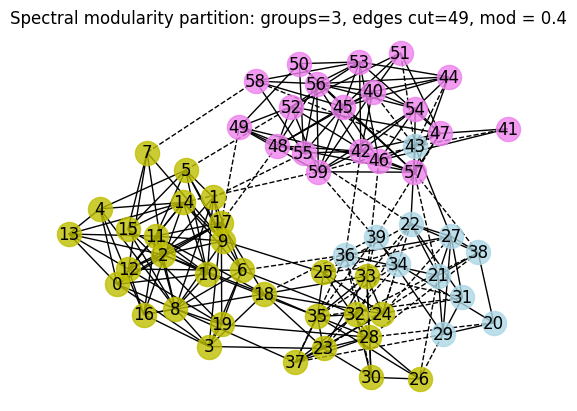

In [65]:
G = affinity_graph
Louvain_partition: list[set[Hashable]] = nx.community.louvain_communities(G,seed = seed)
partition = modularity_spectral_split(G)
while len(partition) < len(Louvain_partition):
    partition = sub_partition(G, partition, partition_method=modularity_spectral_split) 
show_partitions(G, 
                partition, 
                title="Spectral modularity partition:")

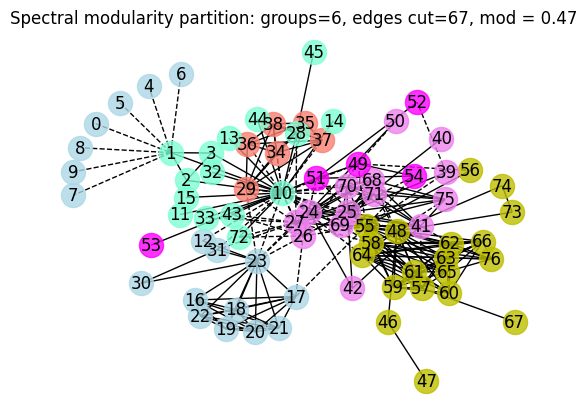

In [61]:
G = les_mis_graph
Louvain_partition: list[set[Hashable]] = nx.community.louvain_communities(G,seed = seed)
partition = modularity_spectral_split(G)
while len(partition) < len(Louvain_partition):
    partition = sub_partition(G, partition, partition_method=modularity_spectral_split) 
show_partitions(G, 
                partition, 
                title="Spectral modularity partition:")

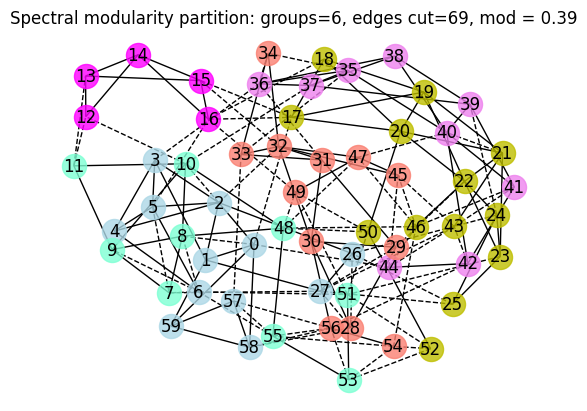

In [62]:
G = small_world
Louvain_partition: list[set[Hashable]] = nx.community.louvain_communities(G,seed = seed)
partition = modularity_spectral_split(G)
while len(partition) < len(Louvain_partition):
    partition = sub_partition(G, partition, partition_method=modularity_spectral_split) 
show_partitions(G, 
                partition, 
                title="Spectral modularity partition:")

---
---

### Question Block C: Partitions Based on Minimum Graph Cut

The minimum graph cut problem doesn't try to find a partition that maximizes modularity. Rather, it tries to find a partition that minimizes the number of edges cut between partitions, while maintaining balance between the groups in the partition. To find more than two groups in the partition you have to apply the algorithm again on one of the groups in the partition.
 
 Import the code from _partitioning\_utilities_. The code is either a slightly modified version of the code you played with in class or a straightforward implementation of finding the fiedler eigenvector as discussed in class.

 Import the graph cut algorithms from _partitioning\_utilities_.

In [66]:
from partitioning_utilities import kernighan_lin_bisection
from partitioning_utilities import laplacian_graph_cut
from partitioning_utilities import normalized_laplacian_graph_cut
from partitioning_utilities import randomwalk_laplacian_graph_cut
from partitioning_utilities import laplacian_graph_cut_sparse
from partitioning_utilities import normalized_laplacian_graph_cut_sparse
from partitioning_utilities import randomwalk_laplacian_graph_cut_sparse
from partitioning_utilities import get_shores_from_eigenvector_median


### Problem 6: Minimum Graph Cut Using the Kernigahn-Lin Algorithm

    Answer problems 6a and 6b before you run any code. Answer problems 6c and 6d after you've run code.

**Problem 6a:**
For each network (affinity graph, Les Miserables graph, small world network), how well with iteratively applying the Kernighan-Lin algorithm will work to find balanced graph cuts?  On which network will it work best and why?



**Problem 6b:**
How much will randomness affect the performance of the algorithm at finding partitions that cut few graph edges? Justify your answer using your understanding of where randomness appears in the Kernighan-Lin algorithm.



**Problem 6c:**
Run the code in the cells below. Were your answers to questions 5a and 5b correct? Why or why not?



**Problem 6d:**
For the affinity network, what patterns (if any) do you see in the modularity and number of edges cut when you compare Newman's hill-climbing algoirthm to the Kernighan-Lin hill-climbing algorithm?



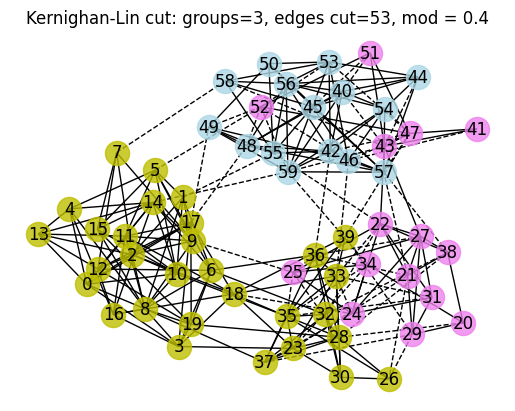

In [67]:
G = affinity_graph
Louvain_partition: list[set[Hashable]] = nx.community.louvain_communities(G,seed = seed)
partition = kernighan_lin_bisection(G)
while len(partition) < len(Louvain_partition):
    partition = sub_partition(G, partition, partition_method=kernighan_lin_bisection) 
show_partitions(G, 
                partition, 
                title="Kernighan-Lin cut:")

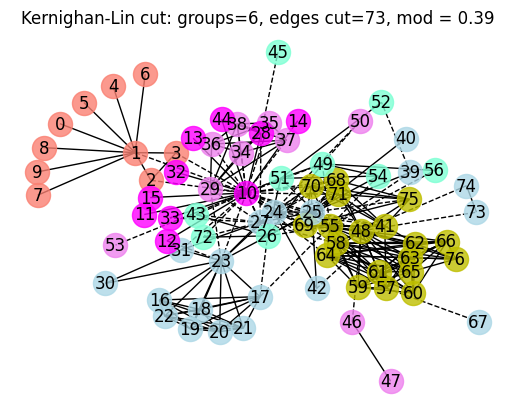

In [68]:
G = les_mis_graph
Louvain_partition: list[set[Hashable]] = nx.community.louvain_communities(G,seed = seed)
partition = kernighan_lin_bisection(G)
while len(partition) < len(Louvain_partition):
    partition = sub_partition(G, partition, partition_method=kernighan_lin_bisection) 
show_partitions(G, 
                partition, 
                title="Kernighan-Lin cut:")

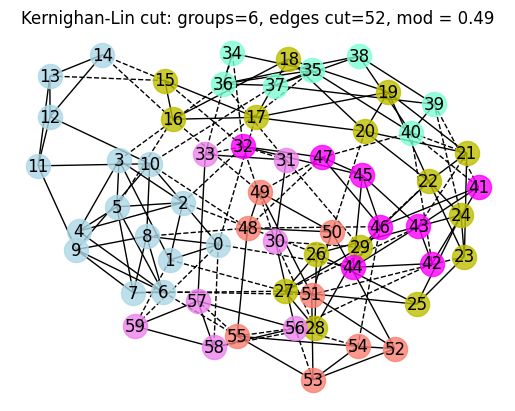

In [69]:
G = small_world
Louvain_partition: list[set[Hashable]] = nx.community.louvain_communities(G,seed = seed)
partition = kernighan_lin_bisection(G)
while len(partition) < len(Louvain_partition):
    partition = sub_partition(G, partition, partition_method=kernighan_lin_bisection) 
show_partitions(G, 
                partition, 
                title="Kernighan-Lin cut:")

---

### Problem 7: Spectral Graph Cut using the Laplacian and Normalized Laplacian Matrices

This question is intended to help you build understanding for how the different types of Laplacians affect the types of partitions formed. Specifically, the Laplacian and normalized Laplacian try to enforce _balance_ differently for the graph cuts.

Run the following three cells, which determine the graph cut using the fiedler eigenvector of the Laplacian. Note that I've hand-tuned the number of groups in the partition rather than setting it to the number of groups found by the Louvain algorithmn. 

In [ ]:
G = affinity_graph
partition = laplacian_graph_cut(G)
while len(partition) < 3:
    partition = sub_partition(G, partition, partition_method=laplacian_graph_cut) 
show_partitions(G, 
                partition, 
                title="Laplacian graph cut:")

In [ ]:
G = les_mis_graph
partition = laplacian_graph_cut(G)
while len(partition) < 4:
    partition = sub_partition(G, partition, partition_method=laplacian_graph_cut) 
show_partitions(G, 
                partition, 
                title="Laplacian graph cut:")

In [ ]:
G = small_world
partition = laplacian_graph_cut(G)
while len(partition) < 4:
    partition = sub_partition(G, partition, partition_method=laplacian_graph_cut) 
show_partitions(G, 
                partition, 
                title="Laplacian graph cut:")

The normalized Laplacian graph cut defines "balance" by trying to have the same number of edges in each group in a binary partition rather than trying to have the same number of nodes in each group. 

     Answer questions 7a, 7b, and 7c after running the three cells above but before running code in the three cells below. Answer question 7d after running the code in the cells.

**Question 7a:**
What do you predict will will be different in the partition for the affinity graph using the normalized Laplacian compared to the partition obtained using the standard Laplacian? Justify your answer using your understanding for how the two types of Laplacians define balance.

**Question 7b:** 
Repeat question 8a for the Les Miserables graph.

**Question 7c:**
Repeat question 8c for the small world network.

**Question 7d:**
Discuss whether your predictions for questions 8a, 8b, and 8c were correct? Discuss what you learned about how different types of definitions for "balance" affect spectral approximations to the minimum graph cut.

In [ ]:
G = affinity_graph
partition = normalized_laplacian_graph_cut(G)
while len(partition) < 3:
    partition = sub_partition(G, partition, partition_method=normalized_laplacian_graph_cut) 
show_partitions(G, 
                partition, 
                title="Normalized Laplacian graph cut:")

In [ ]:
G = les_mis_graph
partition = normalized_laplacian_graph_cut(G)
while len(partition) < 4:
    partition = sub_partition(G, partition, partition_method=normalized_laplacian_graph_cut) 
show_partitions(G, 
                partition, 
                title="Normalized Laplacian graph cut:")

In [ ]:
G = small_world
partition = normalized_laplacian_graph_cut(G)
while len(partition) < 4:
    partition = sub_partition(G, partition, partition_method=normalized_laplacian_graph_cut) 
show_partitions(G, 
                partition, 
                title="Normalized Laplacian graph cut:")

---
---

### Question 8: Which Algorithms Worked "Best"

The purpose of asking the next questions is to help you consolidate the observations you've made in the homework. 

**Question 8a:**
Which algorithm worked best when applied to the affinity graph? Which algorithm worked worst? How did you define best or worst? Jusitfy your answer.

**Question 8b:**
Which algorithm worked best when applied to the Les Miserables graph? Which algorithm worked worst? How did you define best or worst? Jusitfy your answer.

**Question 8c:**
Which algorithm worked best when applied to the small world graph? Which algorithm worked worst? How did you define best or worst? Jusitfy your answer.

---
---